In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import os
from dotenv import load_dotenv
import warnings
from sklearn.model_selection import train_test_split


In [2]:
load_dotenv()

True

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv("DB_PASS"),
    database="georisk_db"
)

In [4]:
query = """
    SELECT 
        l.zone_name, 
        e.recorded_timestamp, 
        e.temperature_c, 
        e.precipitation_mm, 
        e.wind_speed_kmh
    FROM environmental_metrics e
    JOIN locations l ON e.location_id = l.location_id
"""

df = pd.read_sql(query, conn)

conn.close()

df.head()

/tmp/ipykernel_17495/2945788193.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,zone_name,recorded_timestamp,temperature_c,precipitation_mm,wind_speed_kmh
0,bengaluru,2023-01-01 00:00:00,8.9,0.4,11.3
1,bengaluru,2023-01-01 00:00:00,8.9,0.4,11.3
2,bengaluru,2023-01-01 00:00:00,8.9,0.4,11.3
3,bengaluru,2023-01-01 01:00:00,11.1,1.1,10.4
4,bengaluru,2023-01-01 02:00:00,11.1,0.8,9.3


In [5]:
df = df.drop_duplicates()

In [6]:
df['recorded_timestamp'] = pd.to_datetime(df['recorded_timestamp'])
df.head()

,zone_name,recorded_timestamp,temperature_c,precipitation_mm,wind_speed_kmh
0,bengaluru,2023-01-01 00:00:00,8.9,0.4,11.3
3,bengaluru,2023-01-01 01:00:00,11.1,1.1,10.4
4,bengaluru,2023-01-01 02:00:00,11.1,0.8,9.3
5,bengaluru,2023-01-01 03:00:00,11.1,1.9,11.5
6,bengaluru,2023-01-01 04:00:00,10.9,1.0,11.3


In [7]:
df.set_index('recorded_timestamp', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 438816 entries, 2023-01-01 00:00:00 to 2023-01-01 23:00:00
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   zone_name         438816 non-null  object 
 1   temperature_c     438816 non-null  float64
 2   precipitation_mm  438816 non-null  float64
 3   wind_speed_kmh    438816 non-null  float64
dtypes: float64(3), object(1)
memory usage: 16.7+ MB


In [8]:
blr_df = df[df['zone_name'] == 'bengaluru'].copy()

In [9]:
blr_df['7day_avg'] = blr_df['precipitation_mm'].rolling(window=168).mean()

In [10]:
blr_df.tail()

,zone_name,temperature_c,precipitation_mm,wind_speed_kmh,7day_avg
recorded_timestamp,,,,,
2023-01-01 19:00:00,bengaluru,17.7,0.0,15.8,0.013095
2023-01-01 20:00:00,bengaluru,17.2,0.0,14.6,0.013095
2023-01-01 21:00:00,bengaluru,16.6,0.0,12.3,0.013095
2023-01-01 22:00:00,bengaluru,16.0,0.0,10.7,0.013095
2023-01-01 23:00:00,bengaluru,15.6,0.0,9.9,0.013095


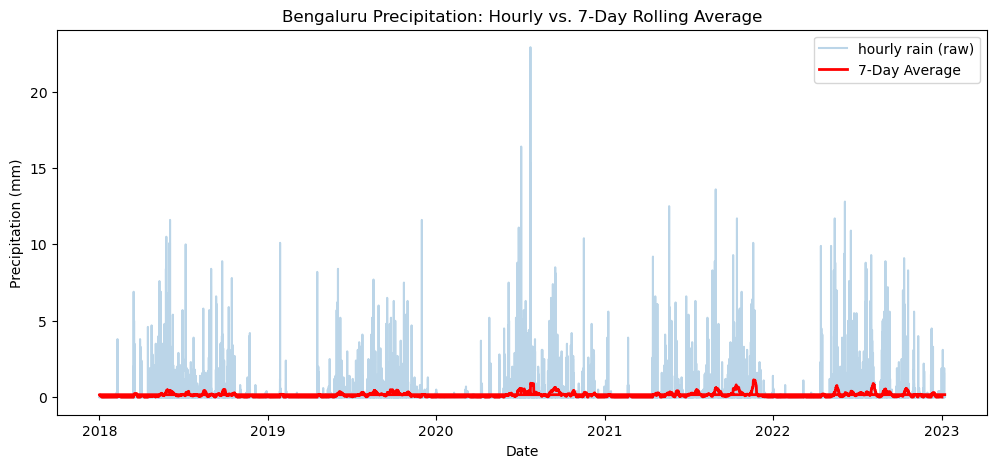

In [11]:
plt.figure(figsize=(12,5))
plt.plot(blr_df.index,blr_df['precipitation_mm'],color='tab:blue',alpha=0.3,label='hourly rain (raw)')
plt.plot(blr_df.index, blr_df['7day_avg'], color='red', linewidth=2, label='7-Day Average')
plt.title('Bengaluru Precipitation: Hourly vs. 7-Day Rolling Average')
plt.ylabel('Precipitation (mm)')
plt.xlabel('Date')
plt.legend()
plt.show()

In [12]:
df['7day_precip_avg'] = df.groupby('zone_name')['precipitation_mm'].transform(lambda x: x.rolling(window=168).mean())

In [13]:
df['24hr_temp'] = df.groupby('zone_name')['temperature_c'].transform(lambda x: x.rolling(window=24).max() - x.rolling(window=24).min())
df.tail()

,zone_name,temperature_c,precipitation_mm,wind_speed_kmh,7day_precip_avg,24hr_temp
recorded_timestamp,,,,,,
2023-01-01 19:00:00,_london,9.5,0.7,7.9,0.163690,3.1
2023-01-01 20:00:00,_london,9.1,0.2,4.9,0.164881,3.3
2023-01-01 21:00:00,_london,8.9,0.2,5.3,0.166071,3.4
2023-01-01 22:00:00,_london,8.7,0.6,5.4,0.169643,3.4
2023-01-01 23:00:00,_london,8.5,0.4,6.6,0.172024,3.4


In [14]:
df = df.copy()
df.tail()

,zone_name,temperature_c,precipitation_mm,wind_speed_kmh,7day_precip_avg,24hr_temp
recorded_timestamp,,,,,,
2023-01-01 19:00:00,_london,9.5,0.7,7.9,0.163690,3.1
2023-01-01 20:00:00,_london,9.1,0.2,4.9,0.164881,3.3
2023-01-01 21:00:00,_london,8.9,0.2,5.3,0.166071,3.4
2023-01-01 22:00:00,_london,8.7,0.6,5.4,0.169643,3.4
2023-01-01 23:00:00,_london,8.5,0.4,6.6,0.172024,3.4


In [15]:
df.dropna(inplace=True)

In [16]:
threshold = df['7day_precip_avg'].quantile(0.90)
df['is_high_risk'] = (df['7day_precip_avg'] > threshold).astype(int)
df['is_high_risk'].value_counts()

is_high_risk
0    393483
1     43496
Name: count, dtype: int64

In [20]:
# dividing the data without shuffling (for obv reasons)
df_encoded = pd.get_dummies(df, columns=['zone_name'], drop_first=True)

X = df_encoded.drop(columns=['is_high_risk', '7day_precip_avg'])
y = df_encoded['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

Training rows: 349583 | Testing rows: 87396


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

tuned_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight={0: 1, 1: 20}, 
    max_depth=10,              
    random_state=42
)

print("Training tuned model...")
tuned_model.fit(X_train, y_train)

print("Predicting future risk...")
tuned_predictions = tuned_model.predict(X_test)

print(classification_report(y_test, tuned_predictions))

Training tuned model...
Predicting future risk...
              precision    recall  f1-score   support

           0       0.97      0.65      0.78     81288
           1       0.13      0.69      0.22      6108

    accuracy                           0.66     87396
   macro avg       0.55      0.67      0.50     87396
weighted avg       0.91      0.66      0.74     87396

